### Calculate Errors
1. Normalized Mean Absolute Error
2. Normalize Root Mean Squared Error
3. Pearson Correlation

Along with global results, India, United States, Brazil and Europe results shown separately as substantial observed generation data is available for these reigons

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr # Keep pearsonr import as it might be used elsewhere or for reference
import geopandas as gpd
from shapely.geometry import Point

In [2]:
# Load the main hybrid model data
hybrid_model_data_all_variables = pd.read_csv("/scratch/shah0012/hybrid_hydropower_model/data/hybrid_model_data/hybrid_model_train_generation_data_1981_2022_selected_variables_snow_cover_historical_plant_lat.csv", parse_dates=['date'])
hybrid_model_data_all_variables = hybrid_model_data_all_variables[["glohydrores_plant_id", "physical_hydropower_0n", "date", "observed_generation_mw", "installed_capacity_mw"]]
hybrid_model_data_all_variables["Month"] = hybrid_model_data_all_variables.date.dt.month

# --- Map plant metadata and perform spatial join for all models ---
GloHydroRes = pd.read_excel("/home/shah0012/GloHydroRes/Output_data/GloHydroRes_vs2.xlsx", sheet_name="Data")
country_shapefile = gpd.read_file("/scratch/shah0012/hybrid_hydropower_model/data/country_shape_file/naturalearth_shapefile/ne_10m_admin_0_countries.shp")


#### Load the hybrid model test results

In [6]:
def load_model_results(base_path, file_name):
    """
    Loads model test results from a CSV file and adds a 'Model' column.

    Args:
        base_path (str): The base directory path for the file.
        file_name (str): The name of the CSV file.

    Returns:
        pd.DataFrame: The loaded and processed DataFrame.

    Raises:
        ValueError: If base_path is not a string or file_name does not end with .csv.
    """
    if not isinstance(base_path, str):
        raise ValueError("base_path must be a string")
    if not file_name.endswith('.csv'):
        raise ValueError(f"File {file_name} does not have a .csv extension")
    
    print(f"Loading file: {base_path + file_name}")
    model_test_result = pd.read_csv(base_path + file_name)
    words = file_name.split("_")[0:2]
    model_name = ' '.join(word.capitalize() for word in words)
    model_test_result["Model"] = model_name
    return model_test_result


#--- Utility Functions to Reduce Repetition ---
def process_model_results(base_path, file_name, main_data):
    """
    Loads, merges, and filters model results for plants with more than 24 months of data
    Returns the filtered DataFrame.
    """

    df = load_model_results(base_path, file_name)
    df["date"] = pd.to_datetime(df["date"], format = "%Y-%m-%d")
    df = df.merge(main_data[["glohydrores_plant_id", "date", "physical_hydropower_0n", "observed_generation_mw"]], on = ["glohydrores_plant_id", "date"], how = "left")
    df["Month"] = df["date"].dt.month
    return df



def map_plant_metadata(df, GloHydroRes):
    """
    Maps plant metadata columns to the DataFrame
    """
    df["plant_lat"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.plant_lat)))
    df["plant_lon"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.plant_lon)))
    df["country"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.country)))
    df["plant_type"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.plant_type)))
    df["instaled_capacity"] = df["glohydrores_plant_id"].map(dict(zip(GloHydroRes.ID, GloHydroRes.capacity_mw)))
    return df

def spatial_join_with_country(df, country_shapefile):
    """
    Performs a spatial join between the DataFrame and the country shapefile.
    """
    geometry = [Point(xy) for xy in zip(df["plant_lon"], df["plant_lat"])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=country_shapefile.crs)
    gdf = gpd.sjoin(gdf, country_shapefile, how='left', predicate='within')
    return gdf
    


model_files = {
    'RF': "rf_test_result_designed_split_target_cf.csv",
    'XGB': "xgb_test_result_designed_split_target_cf.csv",
    'MLR': "lr_test_result_designed_split_target_CF.csv",
    'MLP': "mlp_test_result_designed_split_target_CF.csv"}


model_results = {}
for model, file_name in model_files.items():
    model_results[model] = process_model_results(
        "/scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/",
        file_name,
        hybrid_model_data_all_variables
    )



Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/rf_test_result_designed_split_target_cf.csv
Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/xgb_test_result_designed_split_target_cf.csv
Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/lr_test_result_designed_split_target_CF.csv
Loading file: /scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/mlp_test_result_designed_split_target_CF.csv


#### Calculate Pearson Correlation

In [7]:
# --- Pearson Correlation Calculation Functions ---
def compute_pearson_hybrid(group):
    """
    Computes the Pearson correlation coefficient between observed and predicted hybrid generation.
    Returns NaN if there isn't enough data or if standard deviation is zero.
    """
    if len(group) < 2 or group["observed_generation_mw"].std() == 0 or group["originial_prediction"].std() == 0:
        return pd.Series({"pearson_hybrid": np.nan})
    pearson_corr, _ = pearsonr(group["observed_generation_mw"], group["originial_prediction"])
    return pd.Series({"pearson_hybrid": pearson_corr})

def compute_pearson_physical(group):
    """
    Computes the Pearson correlation coefficient between observed and physical model generation.
    Returns NaN if there isn't enough data or if standard deviation is zero.
    """
    if len(group) < 2 or group["observed_generation_mw"].std() == 0 or group["physical_hydropower_0n"].std() == 0:
        return pd.Series({"pearson_physical": np.nan})
    pearson_corr, _ = pearsonr(group["observed_generation_mw"], group["physical_hydropower_0n"])
    return pd.Series({"pearson_physical": pearson_corr})

# Calculate Pearson correlation by plant for all models
def compute_pearson_by_plant(df):
    pearson_hybrid = df.groupby("glohydrores_plant_id").apply(compute_pearson_hybrid)
    pearson_physical = df.groupby("glohydrores_plant_id").apply(compute_pearson_physical)
    pearson_hybrid.reset_index(inplace=True)
    pearson_physical.reset_index(inplace=True)
    return pearson_hybrid.merge(pearson_physical, on="glohydrores_plant_id", how="left")


pearson_dfs = {}
for model, df in model_results.items():
    print(model)
    pearson_df = compute_pearson_by_plant(df)
    pearson_df = map_plant_metadata(pearson_df, GloHydroRes)
    pearson_df = spatial_join_with_country(pearson_df, country_shapefile)
    pearson_dfs[model] = pearson_df

# --- Print Pearson Correlation Results ---
print("\n--- Pearson Correlation Results ---")

# Overall mean Pearson correlation
print(f"Mean Pearson Correlation of physical model (RF): {pearson_dfs['RF']['pearson_physical'].mean():.4f}")
print(f"Mean Pearson Correlation of hybrid model (RF): {pearson_dfs['RF']['pearson_hybrid'].mean():.4f}")
print(f"Mean Pearson Correlation of hybrid model (XGB): {pearson_dfs['XGB']['pearson_hybrid'].mean():.4f}")
print(f"Mean Pearson Correlation of hybrid model (MLR): {pearson_dfs['MLR']['pearson_hybrid'].mean():.4f}")
print(f"Mean Pearson Correlation of hybrid model (MLP): {pearson_dfs['MLP']['pearson_hybrid'].mean():.4f}")

# Filter ROR and STO plants for RF and XGB models
ROR_plants_RF_pearson = pearson_dfs['RF'][pearson_dfs['RF']["plant_type"] == "ROR"]
STO_plants_RF_pearson = pearson_dfs['RF'][pearson_dfs['RF']["plant_type"] == "STO"]
ROR_plants_XGB_pearson = pearson_dfs['XGB'][pearson_dfs['XGB']["plant_type"] == "ROR"]
STO_plants_XGB_pearson = pearson_dfs['XGB'][pearson_dfs['XGB']["plant_type"] == "STO"]
ROR_plants_MLR_pearson = pearson_dfs['MLR'][pearson_dfs['MLR']["plant_type"] == "ROR"]
STO_plants_MLR_pearson = pearson_dfs['MLR'][pearson_dfs['MLR']["plant_type"] == "STO"]
ROR_plants_MLP_pearson = pearson_dfs['MLP'][pearson_dfs['MLP']["plant_type"] == "ROR"]
STO_plants_MLP_pearson = pearson_dfs['MLP'][pearson_dfs['MLP']["plant_type"] == "STO"]


# Filter plants by continent (Europe) for Pearson correlation
Europe_plants_RF_pearson = pearson_dfs['RF'][pearson_dfs['RF'].CONTINENT == "Europe"]
Europe_plants_XGB_pearson = pearson_dfs['XGB'][pearson_dfs['XGB'].CONTINENT == "Europe"]
Europe_plants_MLR_pearson = pearson_dfs['MLR'][pearson_dfs['MLR'].CONTINENT == "Europe"]
Europe_plants_MLP_pearson = pearson_dfs['MLP'][pearson_dfs['MLR'].CONTINENT == "Europe"]

# Filter ROR and STO plants within Europe for RF and XGB models
Europe_ROR_plants_RF_pearson = Europe_plants_RF_pearson[Europe_plants_RF_pearson["plant_type"] == "ROR"]
Europe_STO_plants_RF_pearson = Europe_plants_RF_pearson[Europe_plants_RF_pearson["plant_type"] == "STO"]
Europe_ROR_plants_XGB_pearson = Europe_plants_XGB_pearson[Europe_plants_XGB_pearson["plant_type"] == "ROR"]
Europe_STO_plants_XGB_pearson = Europe_plants_XGB_pearson[Europe_plants_XGB_pearson["plant_type"] == "STO"]
Europe_ROR_plants_MLR_pearson = Europe_plants_MLR_pearson[Europe_plants_MLR_pearson["plant_type"] == "ROR"]
Europe_STO_plants_MLR_pearson = Europe_plants_MLR_pearson[Europe_plants_MLR_pearson["plant_type"] == "STO"]
Europe_ROR_plants_MLP_pearson = Europe_plants_MLP_pearson[Europe_plants_MLP_pearson["plant_type"] == "ROR"]
Europe_STO_plants_MLP_pearson = Europe_plants_MLP_pearson[Europe_plants_MLP_pearson["plant_type"] == "STO"]

# Filter plants by country (USA) for Pearson correlation
USA_plants_RF_pearson = pearson_dfs['RF'][pearson_dfs['RF'].NAME == "United States of America"]
USA_plants_XGB_pearson = pearson_dfs['XGB'][pearson_dfs['XGB'].NAME == "United States of America"]
USA_plants_MLR_pearson = pearson_dfs['MLR'][pearson_dfs['MLR'].NAME == "United States of America"]
USA_plants_MLP_pearson = pearson_dfs['MLP'][pearson_dfs['MLP'].NAME == "United States of America"]

# Filter ROR and STO plants within USA for RF and XGB models
USA_ROR_plants_RF_pearson = USA_plants_RF_pearson[USA_plants_RF_pearson["plant_type"] == "ROR"]
USA_STO_plants_RF_pearson = USA_plants_RF_pearson[USA_plants_RF_pearson["plant_type"] == "STO"]
USA_ROR_plants_XGB_pearson = USA_plants_XGB_pearson[USA_plants_XGB_pearson["plant_type"] == "ROR"]
USA_STO_plants_XGB_pearson = USA_plants_XGB_pearson[USA_plants_XGB_pearson["plant_type"] == "STO"]
USA_ROR_plants_MLR_pearson = USA_plants_MLR_pearson[USA_plants_MLR_pearson["plant_type"] == "ROR"]
USA_STO_plants_MLR_pearson = USA_plants_MLR_pearson[USA_plants_MLR_pearson["plant_type"] == "STO"]
USA_ROR_plants_MLP_pearson = USA_plants_MLP_pearson[USA_plants_MLP_pearson["plant_type"] == "ROR"]
USA_STO_plants_MLP_pearson = USA_plants_MLP_pearson[USA_plants_MLP_pearson["plant_type"] == "STO"]


# Filter plants by country (Brazil) for Pearson correlation
Brazil_plants_RF_pearson = pearson_dfs['RF'][pearson_dfs['RF'].NAME == "Brazil"]
Brazil_plants_XGB_pearson = pearson_dfs['XGB'][pearson_dfs['XGB'].NAME == "Brazil"]
Brazil_plants_MLR_pearson = pearson_dfs['MLR'][pearson_dfs['MLR'].NAME == "Brazil"]
Brazil_plants_MLP_pearson = pearson_dfs['MLP'][pearson_dfs['MLP'].NAME == "Brazil"]

# Filter ROR and STO plants within Brazil for RF and XGB models
Brazil_ROR_plants_RF_pearson = Brazil_plants_RF_pearson[Brazil_plants_RF_pearson["plant_type"] == "ROR"]
Brazil_STO_plants_RF_pearson = Brazil_plants_RF_pearson[Brazil_plants_RF_pearson["plant_type"] == "STO"]
Brazil_ROR_plants_XGB_pearson = Brazil_plants_XGB_pearson[Brazil_plants_XGB_pearson["plant_type"] == "ROR"]
Brazil_STO_plants_XGB_pearson = Brazil_plants_XGB_pearson[Brazil_plants_XGB_pearson["plant_type"] == "STO"]
Brazil_ROR_plants_MLR_pearson = Brazil_plants_MLR_pearson[Brazil_plants_MLR_pearson["plant_type"] == "ROR"]
Brazil_STO_plants_MLR_pearson = Brazil_plants_MLR_pearson[Brazil_plants_MLR_pearson["plant_type"] == "STO"]
Brazil_ROR_plants_MLP_pearson = Brazil_plants_MLP_pearson[Brazil_plants_MLP_pearson["plant_type"] == "ROR"]
Brazil_STO_plants_MLP_pearson = Brazil_plants_MLP_pearson[Brazil_plants_MLP_pearson["plant_type"] == "STO"]


# Filter plants by country (India) for Pearson correlation
India_plants_RF_pearson = pearson_dfs['RF'][pearson_dfs['RF'].NAME == "India"]
India_plants_XGB_pearson = pearson_dfs['XGB'][pearson_dfs['XGB'].NAME == "India"]
India_plants_MLR_pearson = pearson_dfs['MLR'][pearson_dfs['MLR'].NAME == "India"]
India_plants_MLP_pearson = pearson_dfs['MLP'][pearson_dfs['MLP'].NAME == "India"]


# Filter ROR and STO plants within India for RF and XGB models
India_ROR_plants_RF_pearson = India_plants_RF_pearson[India_plants_RF_pearson["plant_type"] == "ROR"]
India_STO_plants_RF_pearson = India_plants_RF_pearson[India_plants_RF_pearson["plant_type"] == "STO"]
India_ROR_plants_XGB_pearson = India_plants_XGB_pearson[India_plants_XGB_pearson["plant_type"] == "ROR"]
India_STO_plants_XGB_pearson = India_plants_XGB_pearson[India_plants_XGB_pearson["plant_type"] == "STO"]
India_ROR_plants_MLR_pearson = India_plants_MLR_pearson[India_plants_MLR_pearson["plant_type"] == "ROR"]
India_STO_plants_MLR_pearson = India_plants_MLR_pearson[India_plants_MLR_pearson["plant_type"] == "STO"]
India_ROR_plants_MLP_pearson = India_plants_MLP_pearson[India_plants_MLP_pearson["plant_type"] == "ROR"]
India_STO_plants_MLP_pearson = India_plants_MLP_pearson[India_plants_MLP_pearson["plant_type"] == "STO"]



RF
XGB
MLR
MLP

--- Pearson Correlation Results ---
Mean Pearson Correlation of physical model (RF): 0.2476
Mean Pearson Correlation of hybrid model (RF): 0.4865
Mean Pearson Correlation of hybrid model (XGB): 0.4534
Mean Pearson Correlation of hybrid model (MLR): 0.2173
Mean Pearson Correlation of hybrid model (MLP): 0.1022


#### Create final dataframe

In [8]:
# Helper function to build ROR DataFrame for a region
def build_df(physical, rf, xgb, mlr, mlp, region_name):
    df = pd.concat([physical, rf, xgb, mlr, mlp], ignore_index=True)
    df = pd.DataFrame(df, columns=["Pearson Correlation"])
    df["model"] = (
        ["Physical"] * physical.shape[0]
        + ["RF"] * rf.shape[0]
        + ["XGB"] * xgb.shape[0]
        + ["MLR"] * mlr.shape[0]
        + ["MLP"] * mlp.shape[0]
      #  + ["CatBoost"] * Catboost.shape[0]
    )
    df["region"] = region_name
    return df

# Global
ROR_df_global = build_df(
    ROR_plants_RF_pearson["pearson_physical"],
    ROR_plants_RF_pearson["pearson_hybrid"],
    ROR_plants_XGB_pearson["pearson_hybrid"],
    ROR_plants_MLR_pearson["pearson_hybrid"],
    ROR_plants_MLP_pearson["pearson_hybrid"],
    "Global"
)


# Europe
ROR_df_europe = build_df(
    Europe_ROR_plants_RF_pearson["pearson_physical"],
    Europe_ROR_plants_RF_pearson["pearson_hybrid"],
    Europe_ROR_plants_XGB_pearson["pearson_hybrid"],
    Europe_ROR_plants_MLR_pearson["pearson_hybrid"],
    Europe_ROR_plants_MLP_pearson["pearson_hybrid"],
    "Europe"
)


# USA
ROR_df_usa = build_df(
    USA_ROR_plants_RF_pearson["pearson_physical"],
    USA_ROR_plants_RF_pearson["pearson_hybrid"],
    USA_ROR_plants_XGB_pearson["pearson_hybrid"],
    USA_ROR_plants_MLR_pearson["pearson_hybrid"],
    USA_ROR_plants_MLP_pearson["pearson_hybrid"],
    "USA"
)

# Brazil
ROR_df_brazil = build_df(
    Brazil_ROR_plants_RF_pearson["pearson_physical"],
    Brazil_ROR_plants_RF_pearson["pearson_hybrid"],
    Brazil_ROR_plants_XGB_pearson["pearson_hybrid"],
    Brazil_ROR_plants_MLR_pearson["pearson_hybrid"],
    Brazil_ROR_plants_MLP_pearson["pearson_hybrid"],
    "Brazil"
)

# India
ROR_df_india = build_df(
    India_ROR_plants_RF_pearson["pearson_physical"],
    India_ROR_plants_RF_pearson["pearson_hybrid"],
    India_ROR_plants_XGB_pearson["pearson_hybrid"],
    India_ROR_plants_MLR_pearson["pearson_hybrid"],
    India_ROR_plants_MLP_pearson["pearson_hybrid"],
    "India"
)


# Global
STO_df_global = build_df(
    STO_plants_RF_pearson["pearson_physical"],
    STO_plants_RF_pearson["pearson_hybrid"],
    STO_plants_XGB_pearson["pearson_hybrid"],
    STO_plants_MLR_pearson["pearson_hybrid"],
    STO_plants_MLP_pearson["pearson_hybrid"],
    "Global"
)

# Europe
STO_df_europe = build_df(
    Europe_STO_plants_RF_pearson["pearson_physical"],
    Europe_STO_plants_RF_pearson["pearson_hybrid"],
    Europe_STO_plants_XGB_pearson["pearson_hybrid"],
    Europe_STO_plants_MLR_pearson["pearson_hybrid"],
    Europe_STO_plants_MLP_pearson["pearson_hybrid"],
    "Europe"
)

STO_df_usa = build_df(
    USA_STO_plants_RF_pearson["pearson_physical"],
    USA_STO_plants_RF_pearson["pearson_hybrid"],
    USA_STO_plants_XGB_pearson["pearson_hybrid"],
    USA_STO_plants_MLR_pearson["pearson_hybrid"],
    USA_STO_plants_MLP_pearson["pearson_hybrid"],
    "USA"
)

STO_df_brazil = build_df(
    Brazil_STO_plants_RF_pearson["pearson_physical"],
    Brazil_STO_plants_RF_pearson["pearson_hybrid"],
    Brazil_STO_plants_XGB_pearson["pearson_hybrid"],
    Brazil_STO_plants_MLR_pearson["pearson_hybrid"],
    Brazil_STO_plants_MLP_pearson["pearson_hybrid"],
    "Brazil"

)

STO_df_india = build_df(
    India_STO_plants_RF_pearson["pearson_physical"],
    India_STO_plants_RF_pearson["pearson_hybrid"],
    India_STO_plants_XGB_pearson["pearson_hybrid"],
    India_STO_plants_MLR_pearson["pearson_hybrid"],
    India_STO_plants_MLP_pearson["pearson_hybrid"],
    "India"

)


# Concatenate all regions
ROR_df_pearsons = pd.concat([ROR_df_global, ROR_df_europe, ROR_df_usa, ROR_df_brazil, ROR_df_india], ignore_index=True)
STO_df_pearsons = pd.concat([STO_df_global, STO_df_europe, STO_df_usa, STO_df_brazil, STO_df_india], ignore_index=True)

#ROR_df_pearsons.to_csv("/home/shah0012/Hydropower_hybrid_model/figures_related_data/ROR_df_desgined_split.csv", index = False)
#STO_df_pearsons.to_csv("/home/shah0012/Hydropower_hybrid_model/figures_related_data/STO_df_designed_split.csv", index = False)


#### Calculate Normalized Mean Absolute Error

In [ ]:
#model_results["RF"]["Month"] =  model_results["RF"].date.dt.month

# Limit physical hydropower generation to installed capacity
model_results['RF']["physical_hydropower_0n"] = np.where(
    model_results['RF'].physical_hydropower_0n.values > model_results['RF'].installed_capacity_mw.values,
    model_results['RF'].installed_capacity_mw.values,  # if True: use installed capacity
    model_results['RF'].physical_hydropower_0n.values  # if False: use physical hydropower
)

model_results['XGB']["physical_hydropower_0n"] = np.where(
    model_results['XGB'].physical_hydropower_0n.values > model_results['XGB'].installed_capacity_mw.values,
    model_results['XGB'].installed_capacity_mw.values,  # if True: use installed capacity
    model_results['XGB'].physical_hydropower_0n.values  # if False: use physical hydropower
)

model_results['MLR']["physical_hydropower_0n"] = np.where(
    model_results['MLR'].physical_hydropower_0n.values > model_results['MLR'].installed_capacity_mw.values,
    model_results['MLR'].installed_capacity_mw.values,  # if True: use installed capacity
    model_results['MLR'].physical_hydropower_0n.values  # if False: use physical hydropower
)

model_results['MLP']["physical_hydropower_0n"] = np.where(
    model_results['MLP'].physical_hydropower_0n.values > model_results['MLP'].installed_capacity_mw.values,
    model_results['MLP'].installed_capacity_mw.values,  # if True: use installed capacity
    model_results['MLP'].physical_hydropower_0n.values  # if False: use physical hydropower
)

long_term_mean_generation = hybrid_model_data_all_variables.groupby(["glohydrores_plant_id", "Month"])["observed_generation_mw"].mean().reset_index()
long_term_mean_generation.rename(columns={"observed_generation_mw" : "long_term_mean_generation"}, inplace = True)


model_results["RF"] = model_results["RF"][~model_results["RF"]["observed_generation_mw"].isna()]
model_results["XGB"] = model_results["XGB"][~model_results["XGB"]["observed_generation_mw"].isna()]
model_results["MLP"] = model_results["MLP"][~model_results["MLP"]["observed_generation_mw"].isna()]
model_results["MLR"] = model_results["MLR"][~model_results["MLR"]["observed_generation_mw"].isna()]


In [11]:
# --- Mean Absolute Error (MAE) Calculation Functions ---
def compute_mae_hybrid(group):
    """
    Computes the Mean Absolute Error (MAE) between observed and predicted hybrid generation.
    """
    mae = mean_absolute_error(group["observed_generation_mw"], group["originial_prediction"])
    return pd.Series({"mae_hybrid": mae})


def compute_mae_physical(group):
    """
    Computes the Mean Absolute Error (MAE) between observed and physical model generation.
    """
    mae = mean_absolute_error(group["observed_generation_mw"], group["physical_hydropower_0n"])
    return pd.Series({"mae_physical": mae})

def compute_mae_mean(group):
    """
    Computes the Mean Absolute Error (MAE) betwee observed and mean observed generation

    """
    mae = mean_absolute_error(group["observed_generation_mw"], group["observed_generation_mw_long_term"])
    return pd.Series({"mae_mean" : mae})

def compute_mae_by_plant(df):
    mae_hybrid = df.groupby(["glohydrores_plant_id", "Month"]).apply(compute_mae_hybrid)
    mae_physical = df.groupby(["glohydrores_plant_id", "Month"]).apply(compute_mae_physical)
    mae_hybrid.reset_index(inplace = True)
    mae_physical.reset_index(inplace = True)
    return mae_hybrid.merge(mae_physical, on = ["glohydrores_plant_id", "Month"], how = "left")


In [15]:
mae_dfs = {}
for model, df in model_results.items():
    print(model)
    mae_df = compute_mae_by_plant(df)
    mae_df = map_plant_metadata(mae_df, GloHydroRes)
    mae_df = spatial_join_with_country(mae_df, country_shapefile)
    mae_dfs[model] = mae_df

mae_dfs['RF'] = mae_dfs['RF'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")
mae_dfs['XGB'] = mae_dfs['XGB'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")
mae_dfs['MLR'] = mae_dfs['MLR'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")
mae_dfs['MLP'] = mae_dfs['MLP'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")

# Calculate NRMSE hybrid 
mae_dfs['RF']['nmae_hybrid'] = mae_dfs['RF']['mae_hybrid'] / mae_dfs['RF']['long_term_mean_generation']
mae_dfs['XGB']['nmae_hybrid'] = mae_dfs['XGB']['mae_hybrid'] / mae_dfs['XGB']['long_term_mean_generation']
mae_dfs['MLR']['nmae_hybrid'] = mae_dfs['MLR']['mae_hybrid'] / mae_dfs['MLR']['long_term_mean_generation']
mae_dfs['MLP']['nmae_hybrid'] = mae_dfs['MLP']['mae_hybrid'] / mae_dfs['MLP']['long_term_mean_generation']
mae_dfs['RF']['nmae_physical'] = mae_dfs['RF']['mae_physical'] / mae_dfs['RF']['long_term_mean_generation']



RF
XGB
MLR
MLP


In [16]:
ROR_plants_RF_MAE = mae_dfs['RF'][mae_dfs['RF']["plant_type"] == "ROR"]
STO_plants_RF_MAE = mae_dfs['RF'][mae_dfs['RF']["plant_type"] == "STO"]
ROR_plants_XGB_MAE = mae_dfs['XGB'][mae_dfs['XGB']["plant_type"] == "ROR"]
STO_plants_XGB_MAE = mae_dfs['XGB'][mae_dfs['XGB']["plant_type"] == "STO"]
ROR_plants_MLR_MAE = mae_dfs['MLR'][mae_dfs['MLR']["plant_type"] == "ROR"]
STO_plants_MLR_MAE = mae_dfs['MLR'][mae_dfs['MLR']["plant_type"] == "STO"]
ROR_plants_MLP_MAE = mae_dfs['MLP'][mae_dfs['MLP']["plant_type"] == "ROR"]
STO_plants_MLP_MAE = mae_dfs['MLP'][mae_dfs['MLP']["plant_type"] == "STO"]

Europe_plants_RF_mae = mae_dfs['RF'][mae_dfs['RF'].CONTINENT == "Europe"]
Europe_plants_XGB_mae = mae_dfs['XGB'][mae_dfs['XGB'].CONTINENT == "Europe"]
Europe_plants_MLR_mae = mae_dfs['MLR'][mae_dfs['MLR'].CONTINENT == "Europe"]
Europe_plants_MLP_mae = mae_dfs['MLP'][mae_dfs['MLP'].CONTINENT == "Europe"]

Europe_ROR_plants_RF_mae = Europe_plants_RF_mae[Europe_plants_RF_mae["plant_type"] == "ROR"]
Europe_STO_plants_RF_mae = Europe_plants_RF_mae[Europe_plants_RF_mae["plant_type"] == "STO"]
Europe_ROR_plants_XGB_mae = Europe_plants_XGB_mae[Europe_plants_XGB_mae["plant_type"] == "ROR"]
Europe_STO_plants_XGB_mae = Europe_plants_XGB_mae[Europe_plants_XGB_mae["plant_type"] == "STO"]
Europe_ROR_plants_MLR_mae = Europe_plants_MLR_mae[Europe_plants_MLR_mae["plant_type"] == "ROR"]
Europe_STO_plants_MLR_mae = Europe_plants_MLR_mae[Europe_plants_MLR_mae["plant_type"] == "STO"]
Europe_ROR_plants_MLP_mae = Europe_plants_MLP_mae[Europe_plants_MLP_mae["plant_type"] == "ROR"]
Europe_STO_plants_MLP_mae = Europe_plants_MLP_mae[Europe_plants_MLP_mae["plant_type"] == "STO"]


USA_plants_RF_mae = mae_dfs['RF'][mae_dfs['RF'].NAME == "United States of America"]
USA_plants_XGB_mae = mae_dfs['XGB'][mae_dfs['XGB'].NAME == "United States of America"]
USA_plants_MLR_mae = mae_dfs['MLR'][mae_dfs['MLR'].NAME == "United States of America"]
USA_plants_MLP_mae = mae_dfs['MLP'][mae_dfs['MLP'].NAME == "United States of America"]

# Filter ROR and STO plants within USA for RF and XGB models
USA_ROR_plants_RF_mae = USA_plants_RF_mae[USA_plants_RF_mae["plant_type"] == "ROR"]
USA_STO_plants_RF_mae = USA_plants_RF_mae[USA_plants_RF_mae["plant_type"] == "STO"]
USA_ROR_plants_XGB_mae = USA_plants_XGB_mae[USA_plants_XGB_mae["plant_type"] == "ROR"]
USA_STO_plants_XGB_mae = USA_plants_XGB_mae[USA_plants_XGB_mae["plant_type"] == "STO"]
USA_ROR_plants_MLR_mae = USA_plants_MLR_mae[USA_plants_MLR_mae["plant_type"] == "ROR"]
USA_STO_plants_MLR_mae = USA_plants_MLR_mae[USA_plants_MLR_mae["plant_type"] == "STO"]
USA_ROR_plants_MLP_mae = USA_plants_MLP_mae[USA_plants_MLP_mae["plant_type"] == "ROR"]
USA_STO_plants_MLP_mae = USA_plants_MLP_mae[USA_plants_MLP_mae["plant_type"] == "STO"]

# Filter plants by country (Brazil) for NMAE
Brazil_plants_RF_mae = mae_dfs['RF'][mae_dfs['RF'].NAME == "Brazil"]
Brazil_plants_XGB_mae = mae_dfs['XGB'][mae_dfs['XGB'].NAME == "Brazil"]
Brazil_plants_MLR_mae = mae_dfs['MLR'][mae_dfs['MLR'].NAME == "Brazil"]
Brazil_plants_MLP_mae = mae_dfs['MLP'][mae_dfs['MLP'].NAME == "Brazil"]

# Filter ROR and STO plants within Brazil for RF and XGB models
Brazil_ROR_plants_RF_mae = Brazil_plants_RF_mae[Brazil_plants_RF_mae["plant_type"] == "ROR"]
Brazil_STO_plants_RF_mae = Brazil_plants_RF_mae[Brazil_plants_RF_mae["plant_type"] == "STO"]
Brazil_ROR_plants_XGB_mae = Brazil_plants_XGB_mae[Brazil_plants_XGB_mae["plant_type"] == "ROR"]
Brazil_STO_plants_XGB_mae = Brazil_plants_XGB_mae[Brazil_plants_XGB_mae["plant_type"] == "STO"]
Brazil_ROR_plants_MLR_mae = Brazil_plants_MLR_mae[Brazil_plants_MLR_mae["plant_type"] == "ROR"]
Brazil_STO_plants_MLR_mae = Brazil_plants_MLR_mae[Brazil_plants_MLR_mae["plant_type"] == "STO"]
Brazil_ROR_plants_MLP_mae = Brazil_plants_MLP_mae[Brazil_plants_MLP_mae["plant_type"] == "ROR"]
Brazil_STO_plants_MLP_mae = Brazil_plants_MLP_mae[Brazil_plants_MLP_mae["plant_type"] == "STO"]


# Filter plants by country (India) for NMAE
India_plants_RF_mae = mae_dfs['RF'][mae_dfs['RF'].NAME == "India"]
India_plants_XGB_mae = mae_dfs['XGB'][mae_dfs['XGB'].NAME == "India"]
India_plants_MLR_mae = mae_dfs['MLR'][mae_dfs['MLR'].NAME == "India"]
India_plants_MLP_mae = mae_dfs['MLP'][mae_dfs['MLP'].NAME == "India"]


# Filter ROR and STO plants within India for RF and XGB models
India_ROR_plants_RF_mae = India_plants_RF_mae[India_plants_RF_mae["plant_type"] == "ROR"]
India_STO_plants_RF_mae = India_plants_RF_mae[India_plants_RF_mae["plant_type"] == "STO"]
India_ROR_plants_XGB_mae = India_plants_XGB_mae[India_plants_XGB_mae["plant_type"] == "ROR"]
India_STO_plants_XGB_mae = India_plants_XGB_mae[India_plants_XGB_mae["plant_type"] == "STO"]
India_ROR_plants_MLR_mae = India_plants_MLR_mae[India_plants_MLR_mae["plant_type"] == "ROR"]
India_STO_plants_MLR_mae = India_plants_MLR_mae[India_plants_MLR_mae["plant_type"] == "STO"]
India_ROR_plants_MLP_mae = India_plants_MLP_mae[India_plants_MLP_mae["plant_type"] == "ROR"]
India_STO_plants_MLP_mae = India_plants_MLP_mae[India_plants_MLP_mae["plant_type"] == "STO"]



In [21]:
# Global
ROR_df_global = build_df(
    ROR_plants_RF_MAE["nmae_physical"],
    ROR_plants_RF_MAE["nmae_hybrid"],
    ROR_plants_XGB_MAE["nmae_hybrid"],
    ROR_plants_MLR_MAE["nmae_hybrid"],
    ROR_plants_MLP_MAE["nmae_hybrid"],
    "Global"
    )


ROR_df_europe = build_df(
    Europe_ROR_plants_RF_mae["nmae_physical"],
    Europe_ROR_plants_RF_mae["nmae_hybrid"],
    Europe_ROR_plants_XGB_mae["nmae_hybrid"],
    Europe_ROR_plants_MLR_mae["nmae_hybrid"],
    Europe_ROR_plants_MLP_mae["nmae_hybrid"],
    "Europe"
)

ROR_df_usa = build_df(
    USA_ROR_plants_RF_mae["nmae_physical"],
    USA_ROR_plants_RF_mae["nmae_hybrid"],
    USA_ROR_plants_XGB_mae["nmae_hybrid"],
    USA_ROR_plants_MLR_mae["nmae_hybrid"],
    USA_ROR_plants_MLP_mae["nmae_hybrid"],
    "USA"
)


ROR_df_brazil = build_df(
    Brazil_ROR_plants_RF_mae["nmae_physical"],
    Brazil_ROR_plants_RF_mae["nmae_hybrid"],
    Brazil_ROR_plants_XGB_mae["nmae_hybrid"],
    Brazil_ROR_plants_MLR_mae["nmae_hybrid"],
    Brazil_ROR_plants_MLP_mae["nmae_hybrid"],
    "Brazil"
)


ROR_df_india = build_df(
    India_ROR_plants_RF_mae["nmae_physical"],
    India_ROR_plants_RF_mae["nmae_hybrid"],
    India_ROR_plants_XGB_mae["nmae_hybrid"],
    India_ROR_plants_MLR_mae["nmae_hybrid"],
    India_ROR_plants_MLP_mae["nmae_hybrid"],
    "India"
)

ROR_df_mae = pd.concat([ROR_df_global, ROR_df_europe, ROR_df_usa, ROR_df_brazil, ROR_df_india], ignore_index=True)


# Global
STO_df_global = build_df(
    STO_plants_RF_MAE["nmae_physical"],
    STO_plants_RF_MAE["nmae_hybrid"],
    STO_plants_XGB_MAE["nmae_hybrid"],
    STO_plants_MLR_MAE["nmae_hybrid"],
    STO_plants_MLP_MAE["nmae_hybrid"],
    "Global"
)

STO_df_europe = build_df(
    Europe_STO_plants_RF_mae["nmae_physical"],
    Europe_STO_plants_RF_mae["nmae_hybrid"],
    Europe_STO_plants_XGB_mae["nmae_hybrid"],
    Europe_STO_plants_MLR_mae["nmae_hybrid"],  
    Europe_STO_plants_MLP_mae["nmae_hybrid"],
    "Europe"
)

STO_df_usa = build_df(
    USA_STO_plants_RF_mae["nmae_physical"],
    USA_STO_plants_RF_mae["nmae_hybrid"],
    USA_STO_plants_XGB_mae["nmae_hybrid"],
    USA_STO_plants_MLR_mae["nmae_hybrid"],
    USA_STO_plants_MLP_mae["nmae_hybrid"],
    "USA"
)

STO_df_brazil = build_df(
    Brazil_STO_plants_RF_mae["nmae_physical"],
    Brazil_STO_plants_RF_mae["nmae_hybrid"],
    Brazil_STO_plants_XGB_mae["nmae_hybrid"],
    Brazil_STO_plants_MLR_mae["nmae_hybrid"],
    Brazil_STO_plants_MLP_mae["nmae_hybrid"],
    "Brazil"
)

STO_df_india = build_df(
    India_STO_plants_RF_mae["nmae_physical"],
    India_STO_plants_RF_mae["nmae_hybrid"],
    India_STO_plants_XGB_mae["nmae_hybrid"],
    India_STO_plants_MLR_mae["nmae_hybrid"],
    India_STO_plants_MLP_mae["nmae_hybrid"],
    "India"
)


STO_df_mae = pd.concat([STO_df_global, STO_df_europe, STO_df_usa, STO_df_brazil, STO_df_india], ignore_index=True)


#### Normalize Root Mean Sqaured Error

In [18]:
### --- Compute RMSE for each model and each month

def compute_nrmse_hybrid(group):
    rmse = np.sqrt(mean_squared_error(group["observed_generation_mw"], group["originial_prediction"]))
    return pd.Series({"rmse_hybrid": rmse})

def compute_nrmse_physical(group):
    rmse = np.sqrt(mean_squared_error(group["observed_generation_mw"], group["physical_hydropower_0n"]))
    return pd.Series({"rmse_physical": rmse})

def compute_nrmse_by_plant(df):
    rmse_hybrid = df.groupby(["glohydrores_plant_id", "Month"]).apply(compute_nrmse_hybrid)
    rmse_physical = df.groupby(["glohydrores_plant_id", "Month"]).apply(compute_nrmse_physical)
    rmse_hybrid.reset_index(inplace = True)
    rmse_physical.reset_index(inplace = True)
    return rmse_hybrid.merge(rmse_physical, on = ["glohydrores_plant_id", "Month"], how = "left")


rmse_dfs = {}
for model, df in model_results.items():
    rmse_df = compute_nrmse_by_plant(df)
    rmse_df = map_plant_metadata(rmse_df, GloHydroRes)
    rmse_df = spatial_join_with_country(rmse_df, country_shapefile)
    rmse_dfs[model] = rmse_df

rmse_dfs['RF'] = rmse_dfs['RF'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")
rmse_dfs['XGB'] = rmse_dfs['XGB'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")
rmse_dfs['MLR'] = rmse_dfs['MLR'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")
rmse_dfs['MLP'] = rmse_dfs['MLP'].merge(long_term_mean_generation, on = ["glohydrores_plant_id", "Month"], how = "left")


# Calculate NRMSE hybrid
rmse_dfs['RF']['nrmse_hybrid'] = rmse_dfs['RF']['rmse_hybrid'] / rmse_dfs['RF']['long_term_mean_generation']
rmse_dfs['XGB']['nrmse_hybrid'] = rmse_dfs['XGB']['rmse_hybrid'] / rmse_dfs['XGB']['long_term_mean_generation']
rmse_dfs['MLR']['nrmse_hybrid'] = rmse_dfs['MLR']['rmse_hybrid'] / rmse_dfs['MLR']['long_term_mean_generation']
rmse_dfs['MLP']['nrmse_hybrid'] = rmse_dfs['MLP']['rmse_hybrid'] / rmse_dfs['MLP']['long_term_mean_generation']
rmse_dfs['RF']['nrmse_physical'] = rmse_dfs['RF']['rmse_physical'] / rmse_dfs['RF']['long_term_mean_generation']



In [22]:
# Filter ROR and STO plants for RF and XGB models
ROR_plants_RF_RMSE = rmse_dfs['RF'][rmse_dfs['RF']["plant_type"] == "ROR"]
STO_plants_RF_RMSE = rmse_dfs['RF'][rmse_dfs['RF']["plant_type"] == "STO"]
ROR_plants_XGB_RMSE = rmse_dfs['XGB'][rmse_dfs['XGB']["plant_type"] == "ROR"]
STO_plants_XGB_RMSE = rmse_dfs['XGB'][rmse_dfs['XGB']["plant_type"] == "STO"]
ROR_plants_MLR_RMSE = rmse_dfs['MLR'][rmse_dfs['MLR']["plant_type"] == "ROR"]
STO_plants_MLR_RMSE = rmse_dfs['MLR'][rmse_dfs['MLR']["plant_type"] == "STO"]
ROR_plants_MLP_RMSE = rmse_dfs['MLP'][rmse_dfs['MLP']["plant_type"] == "ROR"]
STO_plants_MLP_RMSE = rmse_dfs['MLP'][rmse_dfs['MLP']["plant_type"] == "STO"]

# Filter plants by continent (Europe) for RMSE
Europe_plants_RF_rmse = rmse_dfs['RF'][rmse_dfs['RF'].CONTINENT == "Europe"]
Europe_plants_XGB_rmse = rmse_dfs['XGB'][rmse_dfs['XGB'].CONTINENT == "Europe"]
Europe_plants_MLR_rmse = rmse_dfs['MLR'][rmse_dfs['MLR'].CONTINENT == "Europe"]
Europe_plants_MLP_rmse = rmse_dfs['MLP'][rmse_dfs['MLP'].CONTINENT == "Europe"]

Europe_ROR_plants_RF_rmse = Europe_plants_RF_rmse[Europe_plants_RF_rmse["plant_type"] == "ROR"]
Europe_STO_plants_RF_rmse = Europe_plants_RF_rmse[Europe_plants_RF_rmse["plant_type"] == "STO"]
Europe_ROR_plants_XGB_rmse = Europe_plants_XGB_rmse[Europe_plants_XGB_rmse["plant_type"] == "ROR"]
Europe_STO_plants_XGB_rmse = Europe_plants_XGB_rmse[Europe_plants_XGB_rmse["plant_type"] == "STO"]
Europe_ROR_plants_MLR_rmse = Europe_plants_MLR_rmse[Europe_plants_MLR_rmse["plant_type"] == "ROR"]
Europe_STO_plants_MLR_rmse = Europe_plants_MLR_rmse[Europe_plants_MLR_rmse["plant_type"] == "STO"]
Europe_ROR_plants_MLP_rmse = Europe_plants_MLP_rmse[Europe_plants_MLP_rmse["plant_type"] == "ROR"]
Europe_STO_plants_MLP_rmse = Europe_plants_MLP_rmse[Europe_plants_MLP_rmse["plant_type"] == "STO"]

# Filter plants by country (USA) for RMSE
USA_plants_RF_rmse = rmse_dfs['RF'][rmse_dfs['RF'].NAME == "United States of America"]
USA_plants_XGB_rmse = rmse_dfs['XGB'][rmse_dfs['XGB'].NAME == "United States of America"]
USA_plants_MLR_rmse = rmse_dfs['MLR'][rmse_dfs['MLR'].NAME == "United States of America"]
USA_plants_MLP_rmse = rmse_dfs['MLP'][rmse_dfs['MLP'].NAME == "United States of America"]

# Filter ROR and STO plants within USA for RF and XGB models
USA_ROR_plants_RF_rmse = USA_plants_RF_rmse[USA_plants_RF_rmse["plant_type"] == "ROR"]
USA_STO_plants_RF_rmse = USA_plants_RF_rmse[USA_plants_RF_rmse["plant_type"] == "STO"]
USA_ROR_plants_XGB_rmse = USA_plants_XGB_rmse[USA_plants_XGB_rmse["plant_type"] == "ROR"]
USA_STO_plants_XGB_rmse = USA_plants_XGB_rmse[USA_plants_XGB_rmse["plant_type"] == "STO"]
USA_ROR_plants_MLR_rmse = USA_plants_MLR_rmse[USA_plants_MLR_rmse["plant_type"] == "ROR"]
USA_STO_plants_MLR_rmse = USA_plants_MLR_rmse[USA_plants_MLR_rmse["plant_type"] == "STO"]
USA_ROR_plants_MLP_rmse = USA_plants_MLP_rmse[USA_plants_MLP_rmse["plant_type"] == "ROR"]
USA_STO_plants_MLP_rmse = USA_plants_MLP_rmse[USA_plants_MLP_rmse["plant_type"] == "STO"]

# Filter plants by country (Brazil) for RMSE
Brazil_plants_RF_rmse = rmse_dfs['RF'][rmse_dfs['RF'].NAME == "Brazil"]
Brazil_plants_XGB_rmse = rmse_dfs['XGB'][rmse_dfs['XGB'].NAME == "Brazil"]
Brazil_plants_MLR_rmse = rmse_dfs['MLR'][rmse_dfs['MLR'].NAME == "Brazil"]
Brazil_plants_MLP_rmse = rmse_dfs['MLP'][rmse_dfs['MLP'].NAME == "Brazil"]

# Filter ROR and STO plants within Brazil for RF and XGB models
Brazil_ROR_plants_RF_rmse = Brazil_plants_RF_rmse[Brazil_plants_RF_rmse["plant_type"] == "ROR"]
Brazil_STO_plants_RF_rmse = Brazil_plants_RF_rmse[Brazil_plants_RF_rmse["plant_type"] == "STO"]
Brazil_ROR_plants_XGB_rmse = Brazil_plants_XGB_rmse[Brazil_plants_XGB_rmse["plant_type"] == "ROR"]
Brazil_STO_plants_XGB_rmse = Brazil_plants_XGB_rmse[Brazil_plants_XGB_rmse["plant_type"] == "STO"]
Brazil_ROR_plants_MLR_rmse = Brazil_plants_MLR_rmse[Brazil_plants_MLR_rmse["plant_type"] == "ROR"]
Brazil_STO_plants_MLR_rmse = Brazil_plants_MLR_rmse[Brazil_plants_MLR_rmse["plant_type"] == "STO"]
Brazil_ROR_plants_MLP_rmse = Brazil_plants_MLP_rmse[Brazil_plants_MLP_rmse["plant_type"] == "ROR"]
Brazil_STO_plants_MLP_rmse = Brazil_plants_MLP_rmse[Brazil_plants_MLP_rmse["plant_type"] == "STO"]

# Filter plants by country (India) for RMSE
India_plants_RF_rmse = rmse_dfs['RF'][rmse_dfs['RF'].NAME == "India"]
India_plants_XGB_rmse = rmse_dfs['XGB'][rmse_dfs['XGB'].NAME == "India"]
India_plants_MLR_rmse = rmse_dfs['MLR'][rmse_dfs['MLR'].NAME == "India"]
India_plants_MLP_rmse = rmse_dfs['MLP'][rmse_dfs['MLP'].NAME == "India"]

# Filter ROR and STO plants within India for RF and XGB models
India_ROR_plants_RF_rmse = India_plants_RF_rmse[India_plants_RF_rmse["plant_type"] == "ROR"]
India_STO_plants_RF_rmse = India_plants_RF_rmse[India_plants_RF_rmse["plant_type"] == "STO"]
India_ROR_plants_XGB_rmse = India_plants_XGB_rmse[India_plants_XGB_rmse["plant_type"] == "ROR"]
India_STO_plants_XGB_rmse = India_plants_XGB_rmse[India_plants_XGB_rmse["plant_type"] == "STO"]
India_ROR_plants_MLR_rmse = India_plants_MLR_rmse[India_plants_MLR_rmse["plant_type"] == "ROR"]
India_STO_plants_MLR_rmse = India_plants_MLR_rmse[India_plants_MLR_rmse["plant_type"] == "STO"]
India_ROR_plants_MLP_rmse = India_plants_MLP_rmse[India_plants_MLP_rmse["plant_type"] == "ROR"]
India_STO_plants_MLP_rmse = India_plants_MLP_rmse[India_plants_MLP_rmse["plant_type"] == "STO"]


# Global
ROR_df_global = build_df(
    ROR_plants_RF_RMSE["nrmse_physical"],
    ROR_plants_RF_RMSE["nrmse_hybrid"],
    ROR_plants_XGB_RMSE["nrmse_hybrid"],
    ROR_plants_MLR_RMSE["nrmse_hybrid"],
    ROR_plants_MLP_RMSE["nrmse_hybrid"],
    "Global"
)


# Europe
ROR_df_europe = build_df(
    Europe_ROR_plants_RF_rmse["nrmse_physical"],
    Europe_ROR_plants_RF_rmse["nrmse_hybrid"],
    Europe_ROR_plants_XGB_rmse["nrmse_hybrid"],
    Europe_ROR_plants_MLR_rmse["nrmse_hybrid"],
    Europe_ROR_plants_MLP_rmse["nrmse_hybrid"],
    "Europe"
)


# USA
ROR_df_usa = build_df(
    USA_ROR_plants_RF_rmse["nrmse_physical"],
    USA_ROR_plants_RF_rmse["nrmse_hybrid"],
    USA_ROR_plants_XGB_rmse["nrmse_hybrid"],
    USA_ROR_plants_MLR_rmse["nrmse_hybrid"],
    USA_ROR_plants_MLP_rmse["nrmse_hybrid"],
     "USA"
)


# Brazil
ROR_df_brazil = build_df(
    Brazil_ROR_plants_RF_rmse["nrmse_physical"],
    Brazil_ROR_plants_RF_rmse["nrmse_hybrid"],
    Brazil_ROR_plants_XGB_rmse["nrmse_hybrid"],
    Brazil_ROR_plants_MLR_rmse["nrmse_hybrid"],
    Brazil_ROR_plants_MLP_rmse["nrmse_hybrid"],
    "Brazil"
)


# India
ROR_df_india = build_df(
    India_ROR_plants_RF_rmse["nrmse_physical"],
    India_ROR_plants_RF_rmse["nrmse_hybrid"],
    India_ROR_plants_XGB_rmse["nrmse_hybrid"],
    India_ROR_plants_MLR_rmse["nrmse_hybrid"],
    India_ROR_plants_MLP_rmse["nrmse_hybrid"],
    "India"
)


# Concatenate all regions
ROR_df_nrmse = pd.concat([ROR_df_global, ROR_df_europe, ROR_df_usa, ROR_df_brazil, ROR_df_india], ignore_index=True)

# Global
STO_df_global = build_df(
    STO_plants_RF_RMSE["nrmse_physical"],
    STO_plants_RF_RMSE["nrmse_hybrid"],
    STO_plants_XGB_RMSE["nrmse_hybrid"],
    STO_plants_MLR_RMSE["nrmse_hybrid"],
    STO_plants_MLP_RMSE["nrmse_hybrid"],
    "Global"
)

# Europe
STO_df_europe = build_df(
    Europe_STO_plants_RF_rmse["nrmse_physical"],
    Europe_STO_plants_RF_rmse["nrmse_hybrid"],
    Europe_STO_plants_XGB_rmse["nrmse_hybrid"],
    Europe_STO_plants_MLR_rmse["nrmse_hybrid"],
    Europe_STO_plants_MLP_rmse["nrmse_hybrid"],
    "Europe"
)


sto_df_usa = build_df(
    USA_STO_plants_RF_rmse["nrmse_physical"],
    USA_STO_plants_RF_rmse["nrmse_hybrid"],
    USA_STO_plants_XGB_rmse["nrmse_hybrid"],
    USA_STO_plants_MLR_rmse["nrmse_hybrid"],
    USA_STO_plants_MLP_rmse["nrmse_hybrid"],
    "USA"
)


sto_df_brazil = build_df(
    Brazil_STO_plants_RF_rmse["nrmse_physical"],
    Brazil_STO_plants_RF_rmse["nrmse_hybrid"],
    Brazil_STO_plants_XGB_rmse["nrmse_hybrid"],
    Brazil_STO_plants_MLR_rmse["nrmse_hybrid"],
    Brazil_STO_plants_MLP_rmse["nrmse_hybrid"],
    "Brazil"

)

sto_df_india = build_df(
    India_STO_plants_RF_rmse["nrmse_physical"],
    India_STO_plants_RF_rmse["nrmse_hybrid"],
    India_STO_plants_XGB_rmse["nrmse_hybrid"],
    India_STO_plants_MLR_rmse["nrmse_hybrid"],
    India_STO_plants_MLP_rmse["nrmse_hybrid"],
    "India"

)


STO_df_nrmse = pd.concat([STO_df_global, STO_df_europe, sto_df_usa, sto_df_brazil, sto_df_india], ignore_index=True)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-quality style parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 600
})


In [29]:
# remove global as we are preseting only for four regions
correlation_df_ROR =  ROR_df_pearsons[ROR_df_pearsons["region"] != "Global"]
correlation_df_STO =  STO_df_pearsons[STO_df_pearsons["region"] != "Global"]
nmae_df_STO = ROR_df_mae[ROR_df_mae["region"] != "Global"]
nmae_df_ROR = STO_df_mae[STO_df_mae["region"] != "Global"]
nrmse_df_STO = ROR_df_nrmse[ROR_df_nrmse["region"] != "Global"]
nrmse_df_ROR = STO_df_nrmse[STO_df_nrmse["region"] != "Global"]

# Change Physical to Hydropower Potential
correlation_df_ROR.loc[correlation_df_ROR.model == "Physical", "model"] = "Hydropower Potential"
correlation_df_STO.loc[correlation_df_STO.model == "Physical", "model"] = "Hydropower Potential"
nmae_df_ROR.loc[nmae_df_ROR.model == "Physical", "model"] = "Hydropower Potential"
nmae_df_STO.loc[nmae_df_STO.model == "Physical", "model"] = "Hydropower Potential"
nrmse_df_ROR.loc[nrmse_df_ROR.model == "Physical", "model"] = "Hydropower Potential"
nrmse_df_STO.loc[nrmse_df_STO.model == "Physical", "model"] = "Hydropower Potential"

nmae_df_ROR.rename(columns={"Pearson Correlation" : "NMAE"}, inplace = True)
nmae_df_STO.rename(columns={"Pearson Correlation" : "NMAE"}, inplace = True)

nrmse_df_ROR.rename(columns={"Pearson Correlation" : "NRMSE"}, inplace = True)
nrmse_df_STO.rename(columns={"Pearson Correlation" : "NRMSE"}, inplace = True)


# Define the desired order for 'model' and 'region'
model_order = ["Hydropower Potential", "MLR", "RF", "XGB", "MLP"]
region_order = ["Europe", "USA", "Brazil", "India"]

# Set the categorical order
nrmse_df_ROR["model"] = pd.Categorical(nrmse_df_ROR["model"], categories=model_order, ordered=True)
nrmse_df_ROR["region"] = pd.Categorical(nrmse_df_ROR["region"], categories=region_order, ordered=True)

# Sort by region first, then model
nrmse_df_ROR = nrmse_df_ROR.sort_values(["region", "model"]).reset_index(drop=True)


nrmse_df_STO["model"] = pd.Categorical(nrmse_df_STO["model"], categories=model_order, ordered=True)
nrmse_df_STO["region"] = pd.Categorical(nrmse_df_STO["region"], categories=region_order, ordered=True)

nrmse_df_STO = nrmse_df_STO.sort_values(["region", "model"]).reset_index(drop=True)

nmae_df_ROR["model"] = pd.Categorical(nmae_df_ROR["model"], categories=model_order, ordered=True)
nmae_df_ROR["region"] = pd.Categorical(nmae_df_ROR["region"], categories=region_order, ordered=True)

nmae_df_ROR = nmae_df_ROR.sort_values(["region", "model"]).reset_index(drop=True)

nmae_df_STO["model"] = pd.Categorical(nmae_df_STO["model"], categories=model_order, ordered=True)
nmae_df_STO["region"] = pd.Categorical(nmae_df_STO["region"], categories=region_order, ordered=True)

nmae_df_STO = nmae_df_STO.sort_values(["region", "model"]).reset_index(drop=True)

correlation_df_ROR["model"] = pd.Categorical(correlation_df_ROR["model"], categories=model_order, ordered=True)
correlation_df_ROR["region"] = pd.Categorical(correlation_df_ROR["region"], categories=region_order, ordered=True)

correlation_df_ROR = correlation_df_ROR.sort_values(["region", "model"]).reset_index(drop=True)

correlation_df_STO["model"] = pd.Categorical(correlation_df_STO["model"], categories=model_order, ordered=True)
correlation_df_STO["region"] = pd.Categorical(correlation_df_STO["region"], categories=region_order, ordered=True)

correlation_df_STO = correlation_df_STO.sort_values(["region", "model"]).reset_index(drop=True)


/home/shah0012/.conda/envs/python_env/lib/python3.7/site-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
/home/shah0012/.conda/envs/python_env/lib/python3.7/site-packages/pandas/core/frame.py:5047: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,
/home/shah0012/.conda/envs/python_env/lib/python3.7/site-packages/ipykernel_launcher.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

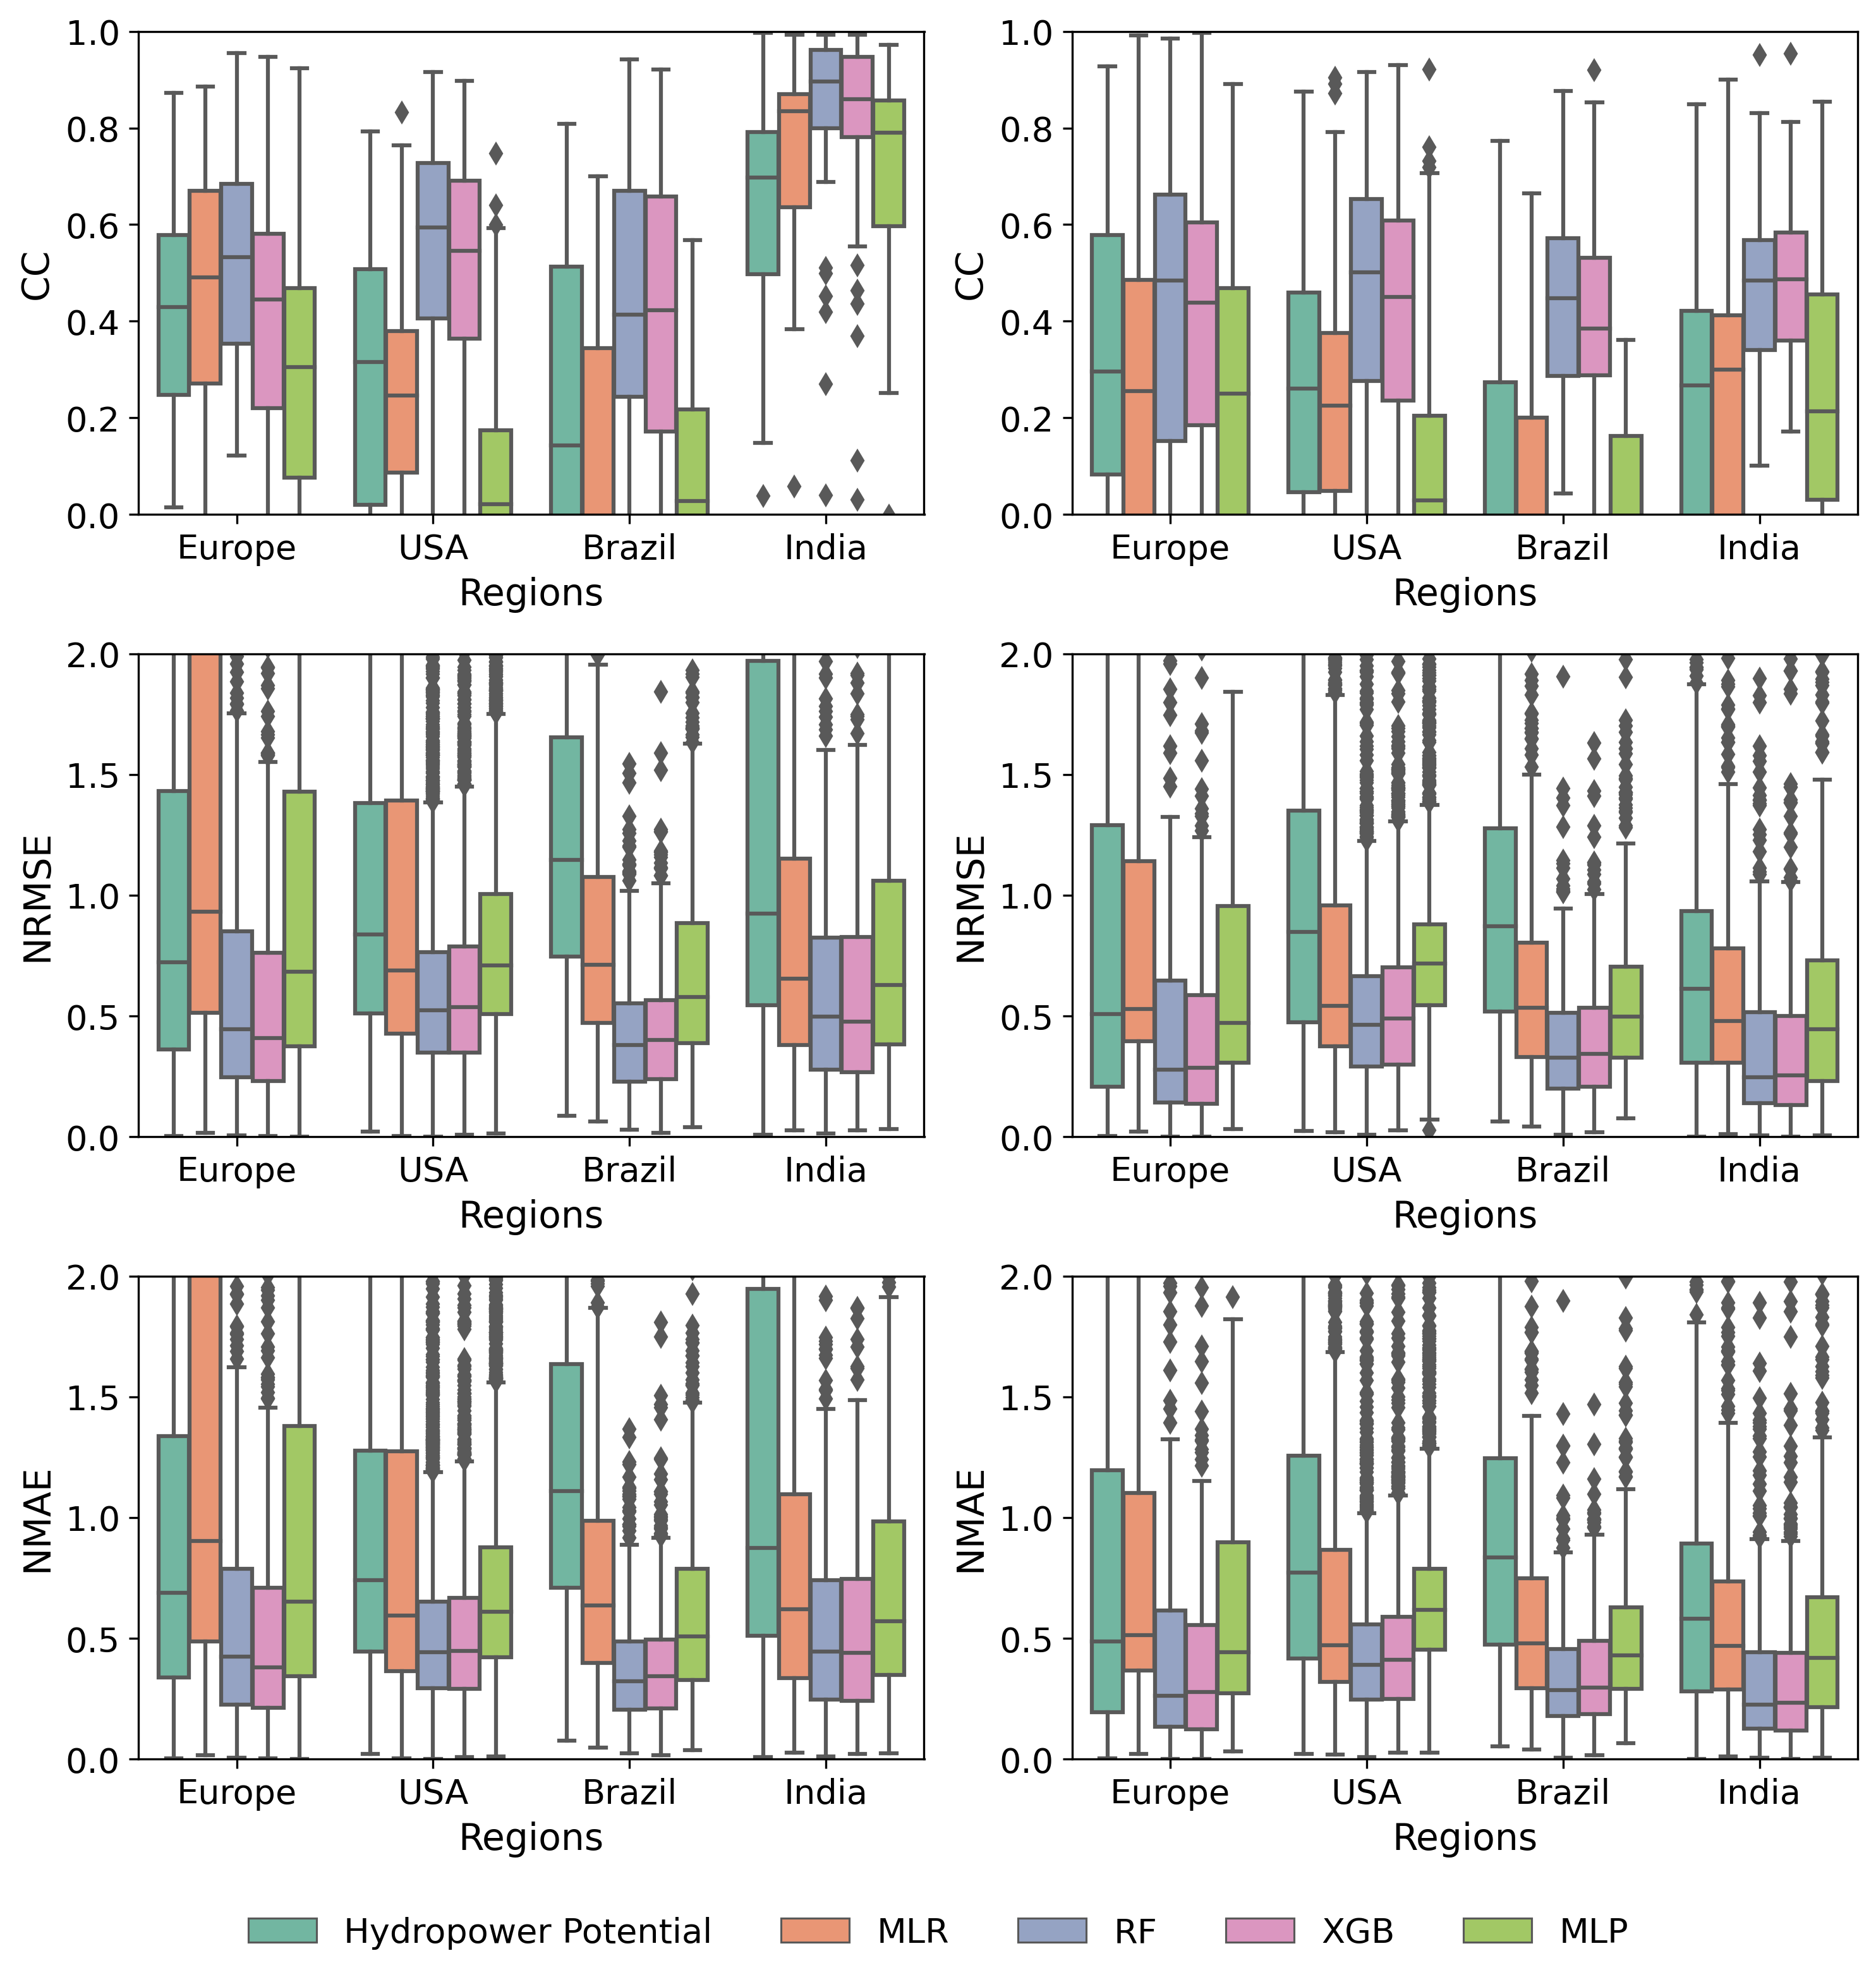

In [ ]:
 
fig, axs = plt.subplots(3, 2, figsize = (10, 10))

sns.boxplot(data = correlation_df_ROR, x = "region", y = "Pearson Correlation", ax = axs[0, 0], hue = "model", palette = "Set2")
axs[0, 0].set_xlabel("Regions", size = 14)
axs[0, 0].set_ylabel("CC", size = 14)
axs[0, 0].get_legend().remove()
axs[0, 0].set_ylim(0, 1)
axs[0, 0].tick_params(labelsize = 13)

sns.boxplot(data = correlation_df_STO, x = "region", y = "Pearson Correlation", ax = axs[0, 1], hue = "model", palette = "Set2")
axs[0, 1].set_xlabel("Regions", size = 14)
axs[0, 1].set_ylabel("CC", size = 14)
axs[0,1].get_legend().remove()
axs[0, 1].set_ylim(0, 1)
axs[0,1].tick_params(labelsize = 13)




sns.boxplot(data = nrmse_df_ROR, x = "region", y = "NRMSE", ax = axs[1, 0], hue = "model", palette = "Set2")
axs[1, 0].set_xlabel("Regions", size = 14)
axs[1, 0].set_ylabel("NRMSE", size = 14)
axs[1, 0].get_legend().remove()#axs[1, 0].set_xticklabels(["Physical", "RF", "XGB", "MLR", "MLP"])
axs[1, 0].set_ylim(0, 2)
axs[1, 0].tick_params(labelsize = 13)

sns.boxplot(data = nrmse_df_STO, x = "region", y = "NRMSE", ax = axs[1, 1], hue = "model", palette = "Set2")
axs[1, 1].set_xlabel("Regions", size = 14)
axs[1, 1].set_ylabel("NRMSE", size = 14)
axs[1, 1].get_legend().remove()
axs[1, 1].set_ylim(0, 2)
axs[1, 1].tick_params(labelsize = 13)

sns.boxplot(data = nmae_df_ROR, x = "region", y = "NMAE", ax = axs[2, 0], hue = "model", palette = "Set2")
axs[2, 0].set_xlabel("Regions", size = 14)
axs[2, 0].set_ylabel("NMAE", size = 14)
axs[2,0].get_legend().remove()#axs[2, 0].set_xticklabels(["Physical", "RF", "XGB", "MLR", "MLP"])
axs[2, 0].set_ylim(0, 2)
axs[2, 0].tick_params(labelsize = 13)

sns.boxplot(data = nmae_df_STO, x = "region", y = "NMAE", ax = axs[2, 1], hue = "model", palette = "Set2")
axs[2, 1].set_xlabel("Regions", size = 14)
axs[2, 1].set_ylabel("NMAE", size = 14)
axs[2,1].get_legend().remove()#axs[2, 1].set_xticklabels(["Physical", "RF", "XGB", "MLR", "MLP"])
axs[2, 1].set_ylim(0, 2)
axs[2, 1].tick_params(labelsize = 13)



handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=13, title_fontsize=10)
plt.tight_layout()
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/boxplot_error_attributes_designed_split_target_CF.pdf", dpi = 300, format = "pdf", bbox_inches = "tight")

plt.show()

#### Calculate Statistics for the paper

In [ ]:
nrmse_df_ROR_physical = nrmse_df_ROR[nrmse_df_ROR.model == "Hydropower Potential"].groupby("region").median().reset_index()
nrmse_df_ROR_physical.rename(columns={"NRMSE" : "nrmse_physical"}, inplace = True)
nrmse_df_ROR_rf = nrmse_df_ROR[nrmse_df_ROR.model == "RF"].groupby("region").median().reset_index()
nrmse_df_ROR_rf.rename(columns={"NRMSE" : "nrmse_rf"}, inplace = True)
nrmse_df_ROR_xgb = nrmse_df_ROR[nrmse_df_ROR.model == "XGB"].groupby("region").median().reset_index()
nrmse_df_ROR_xgb.rename(columns={"NRMSE" : "nrmse_xgb"}, inplace = True)
nrmse_df_ROR_mlr = nrmse_df_ROR[nrmse_df_ROR.model == "MLR"].groupby("region").median().reset_index()
nrmse_df_ROR_mlr.rename(columns={"NRMSE" : "nrmse_mlr"}, inplace = True)
nrmse_df_ROR_mlp = nrmse_df_ROR[nrmse_df_ROR.model == "MLP"].groupby("region").median().reset_index()
nrmse_df_ROR_mlp.rename(columns={"NRMSE" : "nrmse_mlp"}, inplace = True)

nrmse_merge = nrmse_df_ROR_physical.merge(nrmse_df_ROR_rf, on = "region", how = "left")
nrmse_merge = nrmse_merge.merge(nrmse_df_ROR_xgb, on = "region", how = "left")
nrmse_merge = nrmse_merge.merge(nrmse_df_ROR_mlr, on = "region", how = "left")
nrmse_merge = nrmse_merge.merge(nrmse_df_ROR_mlp, on = "region", how = "left")

nrmse_merge["percentage_improvement_rf"] = (nrmse_merge["nrmse_physical"] - nrmse_merge["nrmse_rf"]) / nrmse_merge["nrmse_physical"] * 100
nrmse_merge["percentage_improvement_xgb"] = (nrmse_merge["nrmse_physical"] - nrmse_merge["nrmse_xgb"]) / nrmse_merge["nrmse_physical"] * 100
nrmse_merge["percentage_improvement_mlr"] = (nrmse_merge["nrmse_physical"] - nrmse_merge["nrmse_mlr"]) / nrmse_merge["nrmse_physical"] * 100
nrmse_merge["percentage_improvement_mlp"] = (nrmse_merge["nrmse_physical"] - nrmse_merge["nrmse_mlp"]) / nrmse_merge["nrmse_physical"] * 100

print(nrmse_merge[["region", "nrmse_physical", "nrmse_rf", "nrmse_xgb", "nrmse_mlr", "nrmse_mlp"]])


nrmse_df_STO_physical = nrmse_df_STO[nrmse_df_STO.model == "Hydropower Potential"].groupby("region").median().reset_index()
nrmse_df_STO_physical.rename(columns={"NRMSE" : "nrmse_physical"}, inplace = True)
nrmse_df_STO_rf = nrmse_df_STO[nrmse_df_STO.model == "RF"].groupby("region").median().reset_index()
nrmse_df_STO_rf.rename(columns={"NRMSE" : "nrmse_rf"}, inplace = True)
nrmse_df_STO_xgb = nrmse_df_STO[nrmse_df_STO.model == "XGB"].groupby("region").median().reset_index()
nrmse_df_STO_xgb.rename(columns={"NRMSE" : "nrmse_xgb"}, inplace = True)
nrmse_df_STO_mlr = nrmse_df_STO[nrmse_df_STO.model == "MLR"].groupby("region").median().reset_index()
nrmse_df_STO_mlr.rename(columns={"NRMSE" : "nrmse_mlr"}, inplace = True)
nrmse_df_STO_mlp = nrmse_df_STO[nrmse_df_STO.model == "MLP"].groupby("region").median().reset_index()
nrmse_df_STO_mlp.rename(columns={"NRMSE" : "nrmse_mlp"}, inplace = True)

nrmse_merge_STO = nrmse_df_STO_physical.merge(nrmse_df_STO_rf, on = "region", how = "left")
nrmse_merge_STO = nrmse_merge_STO.merge(nrmse_df_STO_xgb, on = "region", how = "left")
nrmse_merge_STO = nrmse_merge_STO.merge(nrmse_df_STO_mlr, on = "region", how = "left")
nrmse_merge_STO = nrmse_merge_STO.merge(nrmse_df_STO_mlp, on = "region", how = "left")

nrmse_merge_STO["percentage_improvement_rf"] = (nrmse_merge_STO["nrmse_physical"] - nrmse_merge_STO["nrmse_rf"]) / nrmse_merge_STO["nrmse_physical"] * 100
nrmse_merge_STO["percentage_improvement_xgb"] = (nrmse_merge_STO["nrmse_physical"] - nrmse_merge_STO["nrmse_xgb"]) / nrmse_merge_STO["nrmse_physical"] * 100
nrmse_merge_STO["percentage_improvement_mlr"] = (nrmse_merge_STO["nrmse_physical"] - nrmse_merge_STO["nrmse_mlr"]) / nrmse_merge_STO["nrmse_physical"] * 100
nrmse_merge_STO["percentage_improvement_mlp"] = (nrmse_merge_STO["nrmse_physical"] - nrmse_merge_STO["nrmse_mlp"]) / nrmse_merge_STO["nrmse_physical"] * 100

print(nrmse_merge_STO[["region", "nrmse_physical", "nrmse_rf", "nrmse_xgb", "nrmse_mlr", "nrmse_mlp"]])


